# Data Visualization

# seaborn

## Imports

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import missingno as msno

## Getting datasets names in seaborn

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

## Task 1: Seaborn Multiple Subplots

use flights dataset and create two subplots:

1. Histogram showing the distribution of passengers with KDE.
2. Scatter plot showing the relationship between year and passengers, colored by month.

In [3]:
flight = sns.load_dataset("flights")
flight.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


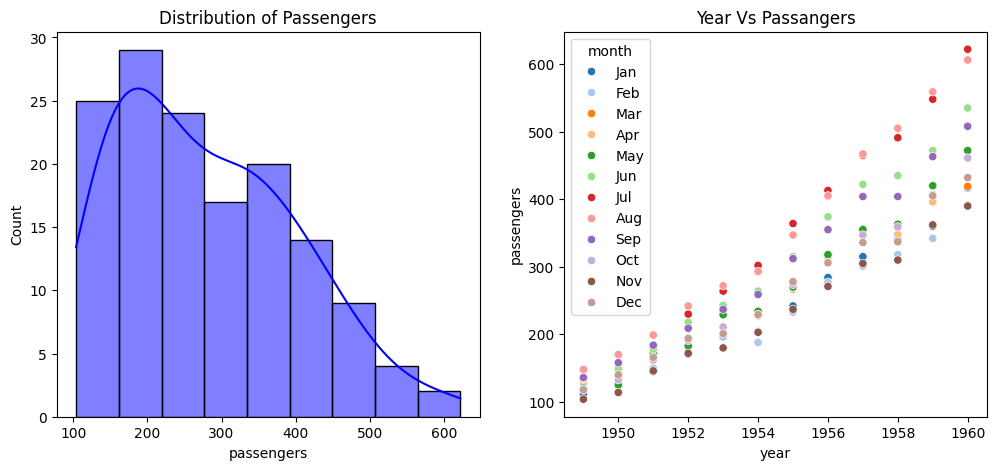

In [4]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.histplot(flight["passengers"], kde=True, ax=axes[0], color="blue")
axes[0].set_title("Distribution of Passengers")

sns.scatterplot(data=flight, x="year", y="passengers", hue="month", ax=axes[1], palette="tab20")
axes[1].set_title("Year Vs Passangers")

plt.show()

## Task 2: Flights Dataset: Plot Analysis

### 1. how did the total nu,ber of airline passengers change from 1949 to 1960

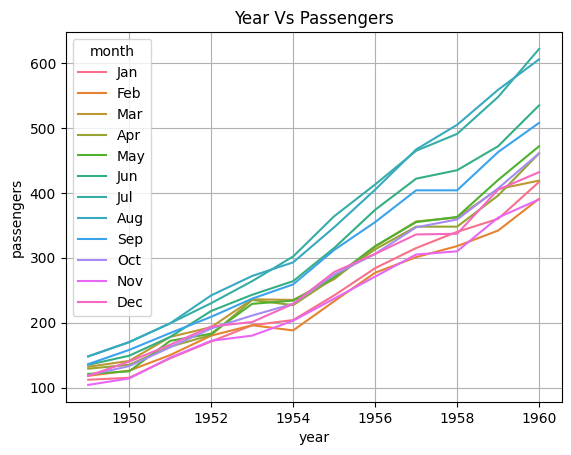

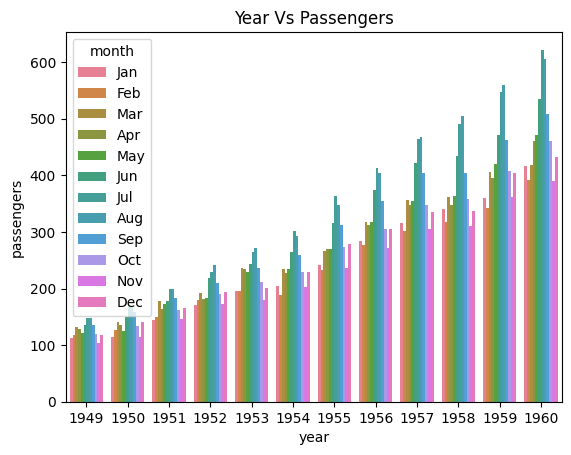

In [5]:
sns.lineplot(data=flight, x="year", y="passengers", hue="month")
plt.title("Year Vs Passengers")
plt.grid()
plt.show()

sns.barplot(data=flight, x="year", y="passengers", hue="month")

plt.title("Year Vs Passengers")
plt.show()

### 2. how did passenger count change over years for a single month

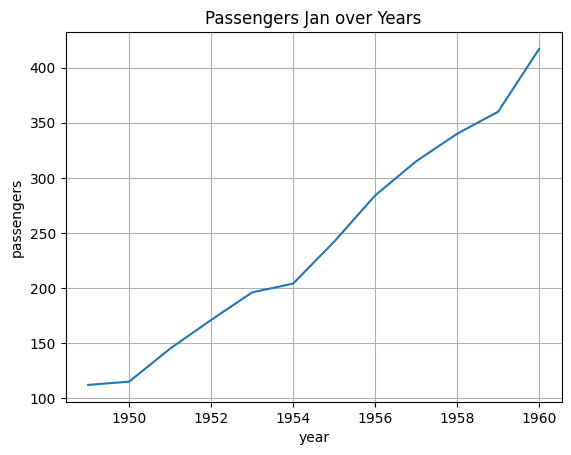

In [6]:
mon = "Jan"
flight_mon = flight[flight["month"] == mon]
sns.lineplot(data=flight_mon, x="year", y="passengers")
plt.title(f"Passengers {mon.title()} over Years")
plt.grid()
plt.show()

### 3. in a chossen year which month had a higher passenger counts?

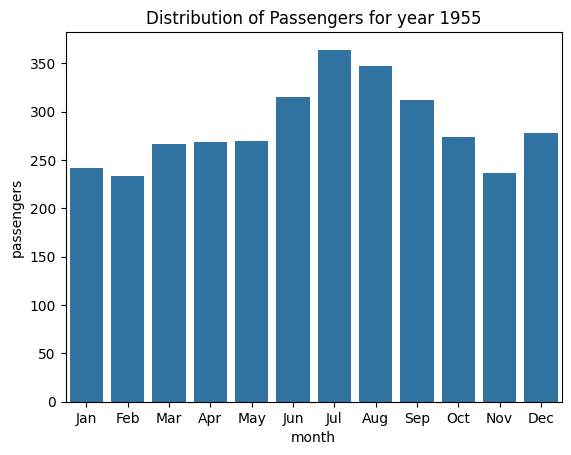

In [7]:
yer = 1955
flight_year = flight[flight["year"] == yer]
sns.barplot(data=flight_year, x="month", y="passengers")
plt.title(f"Distribution of Passengers for year {yer}")
plt.show()

### 4. from 1949-1960 does jan and july show

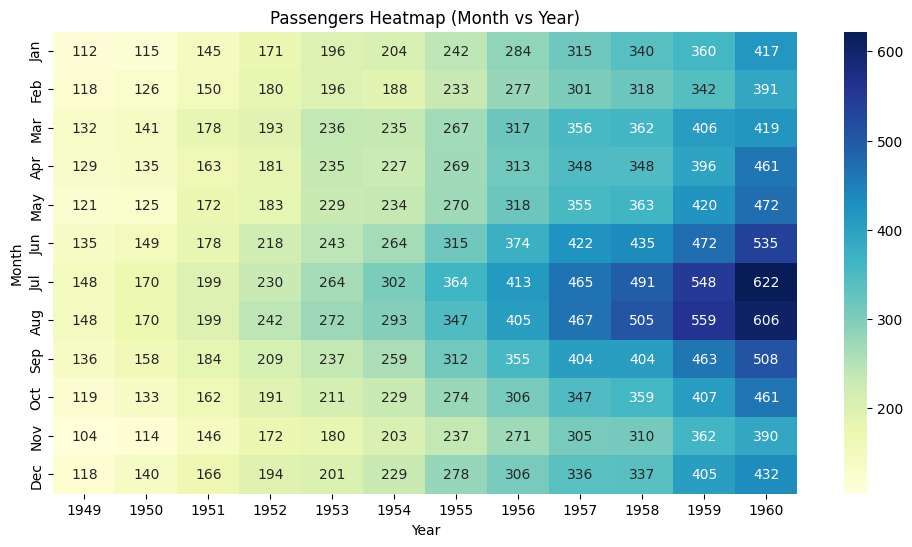

In [8]:
pivot = flight.pivot(index="month", columns="year", values="passengers")

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlGnBu", annot=True, fmt="d")

plt.title("Passengers Heatmap (Month vs Year)")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()

### 5. From 1949–1960, did passenger numbers grow at the same rate for every month, or do some months increase faster over the years?

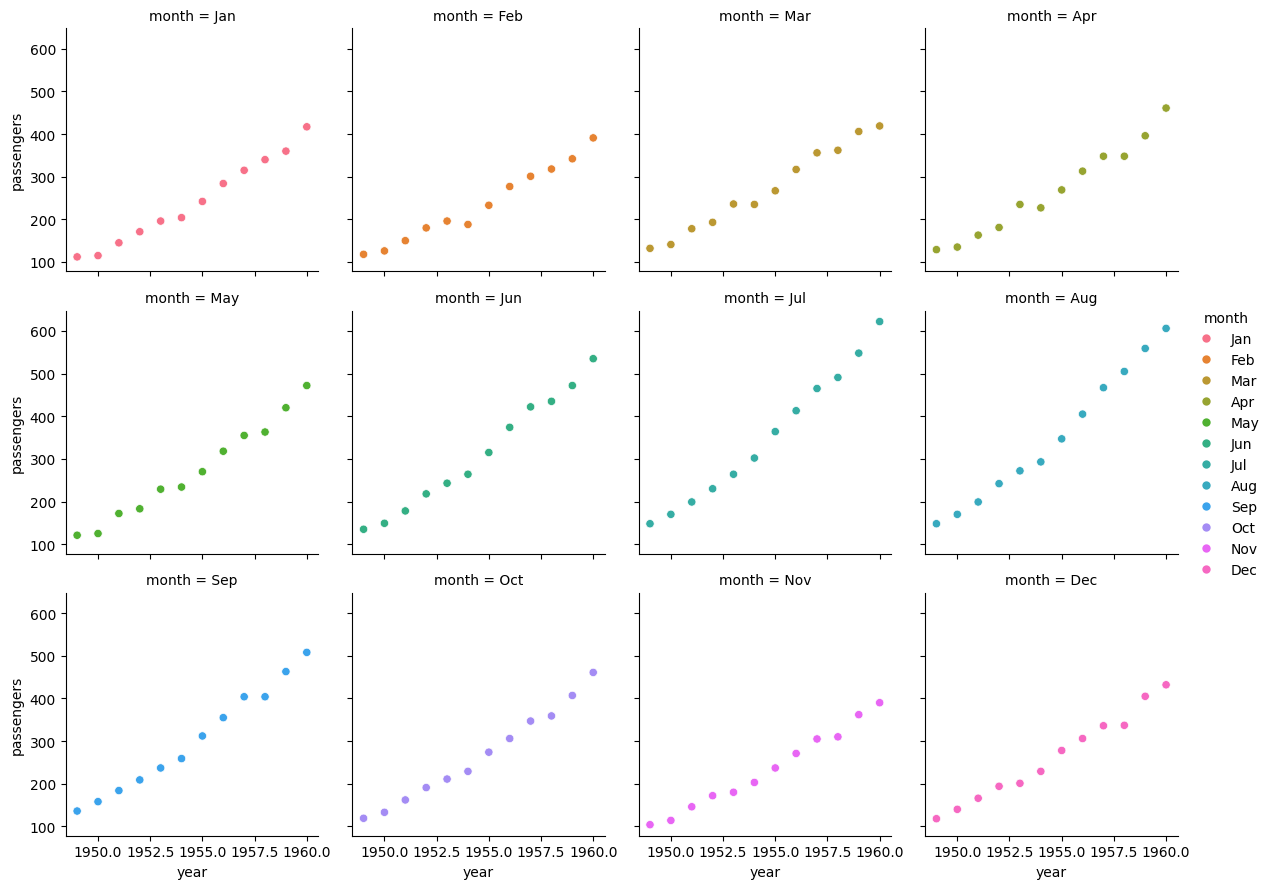

In [9]:
sns.relplot(
    data=flight,
    x="year",
    y="passengers",
    col="month",
    hue="month",
    col_wrap=4,
    kind="scatter",
    height=3,
    aspect=1
)

plt.show()

## Task 3: Exploring the planets Dataset

In [10]:
plan = sns.load_dataset("planets")
plan.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


### 1. Which column has the highest number of missing values?

In [11]:
missing_vals = plan.isnull().sum().sort_values(ascending=False)
missing_vals[missing_vals > 0]

mass              522
distance          227
orbital_period     43
dtype: int64

### 2. Which two columns have strongest missing-value relationship?

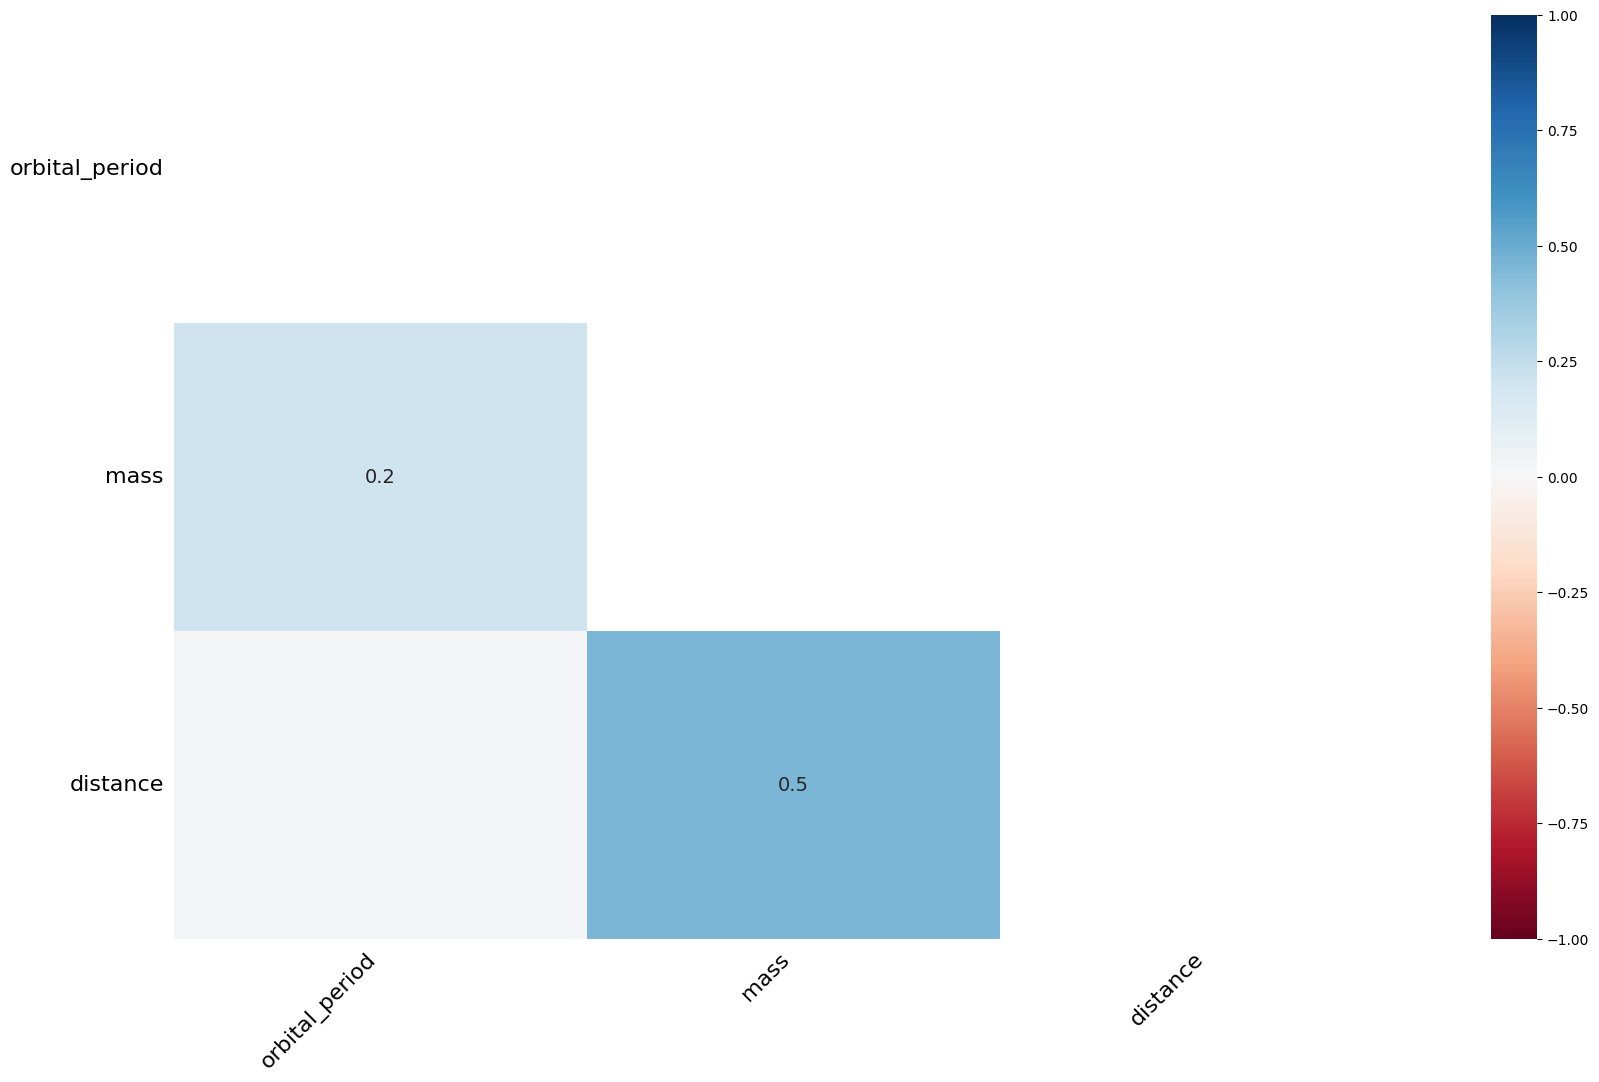

In [12]:
msno.heatmap(plan)
plt.show()

### 3. Which method shows a sharp rise in discoveries after 2009?

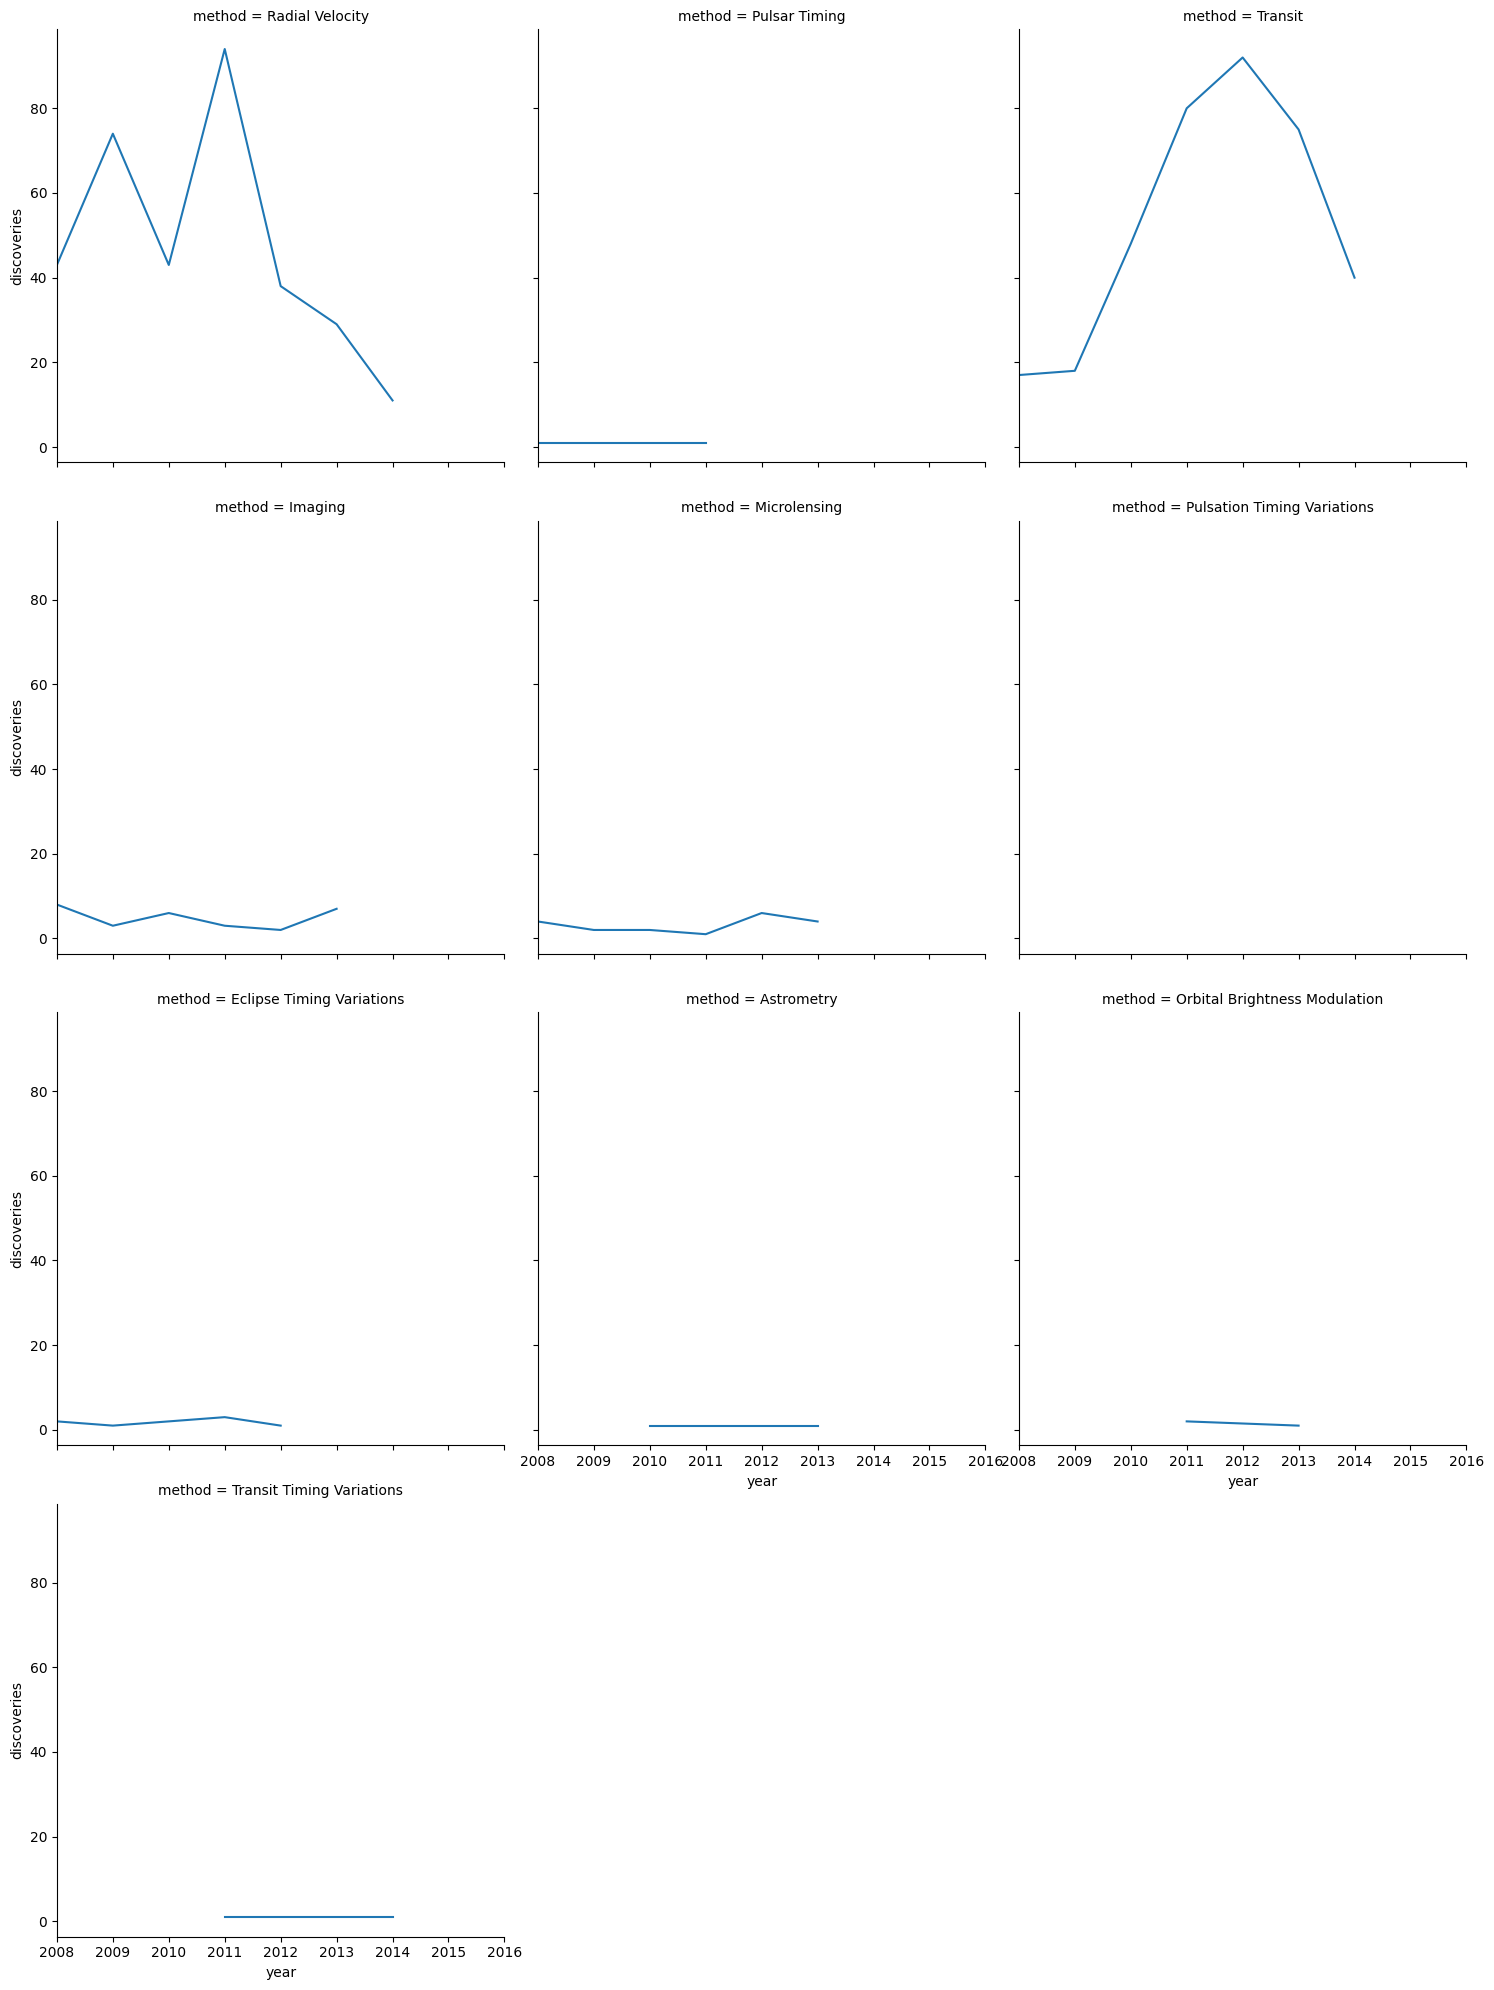

In [13]:
disc = plan.groupby(["year","method"]).size().reset_index(name="discoveries")

sns.relplot(
    data=disc,
    x="year",
    y="discoveries",
    kind="line",
    col="method",
    col_wrap=3
)

plt.xlim(2008,2016)
plt.show()

### 4. Fill the missing values of the distance column using column mean.

In [14]:
plan["distance"] = plan["distance"].fillna(plan["distance"].mean())

### 5. Arrange the dataset in chronological order using the year column. Then fill the missing values in method using forward fill (ffill).

In [15]:
plan = plan.sort_values("year")
plan["method"] = plan["method"].fillna(method="ffill")
plan.head()

C:\Users\AsUS\AppData\Local\Temp\ipykernel_784\446540393.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  plan["method"] = plan["method"].fillna(method="ffill")


,method,number,orbital_period,mass,distance,year
441,Radial Velocity,1,83.888000,11.680,40.570000,1989
942,Pulsar Timing,3,66.541900,NaN,264.069282,1992
941,Pulsar Timing,3,25.262000,NaN,264.069282,1992
943,Pulsar Timing,3,98.211400,NaN,264.069282,1994
16,Radial Velocity,1,4.230785,0.472,15.360000,1995


## Task 4: Plotting with Seaborn

In [16]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 1. Visualize the relationship between the total bill amount and tip amount. Differentiate smokers and non-smokers and represent gender.

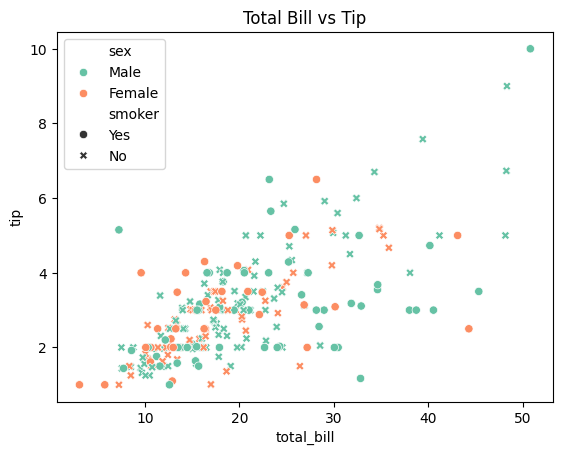

In [17]:
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex",
    style="smoker",
    palette="Set2"
)

plt.title("Total Bill vs Tip")
plt.show()

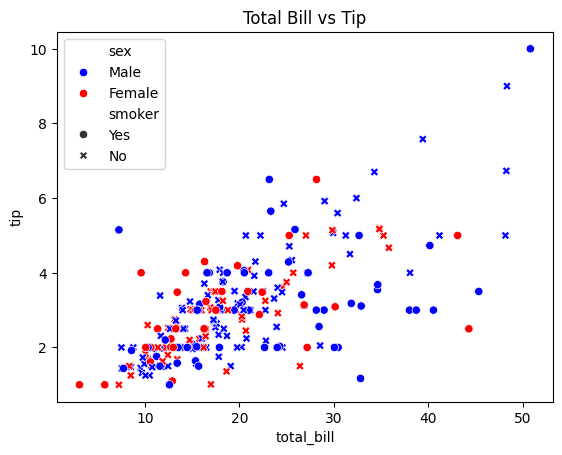

In [18]:
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex",
    style="smoker",
    palette={
        "Male": "blue",
        "Female": "red"
    }
)

plt.title("Total Bill vs Tip")
plt.show()

### 2. Show how the average total bill changes with table size. Compare males and females separately and also distinguish lunch and dinner.

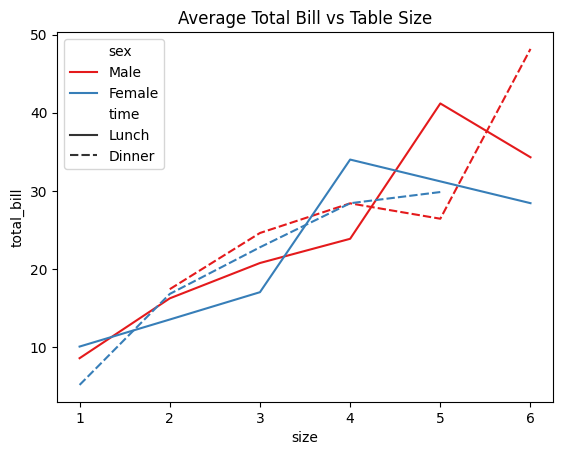

In [19]:
sns.lineplot(
    data=tips,
    x="size",
    y="total_bill",
    hue="sex",
    style="time",
    estimator="mean",
    errorbar=None,
    palette="Set1"
)

plt.title("Average Total Bill vs Table Size")
plt.show()

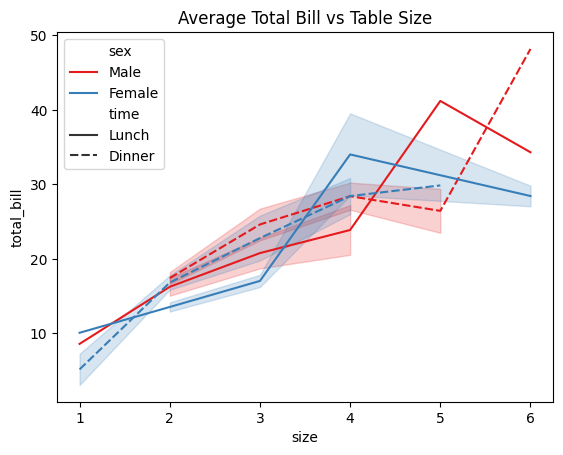

In [20]:
sns.lineplot(
    data=tips,
    x="size",
    y="total_bill",
    hue="sex",
    style="time",
    estimator="mean",
    errorbar="se",
    palette="Set1"
)

plt.title("Average Total Bill vs Table Size")
plt.show()

### 3. Plot the distribution of total bill amounts for males and females together. Use density instead of frequency and include a smooth distribution curve.

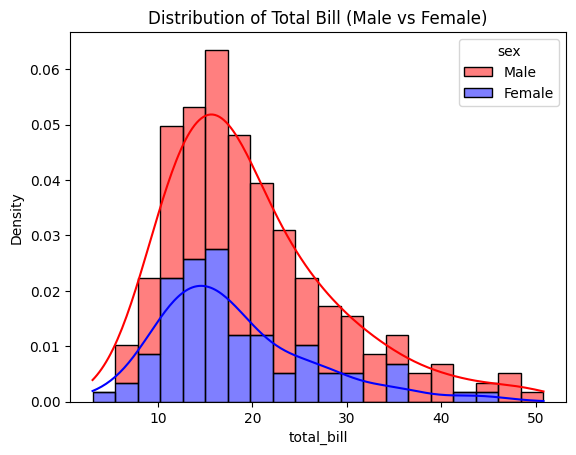

In [21]:
sns.histplot(
    data=tips,
    x="total_bill",
    hue="sex",
    bins=20,
    stat="density",
    kde=True,
    multiple="stack",
    palette={"red", "blue"}
)

plt.title("Distribution of Total Bill (Male vs Female)")
plt.show()

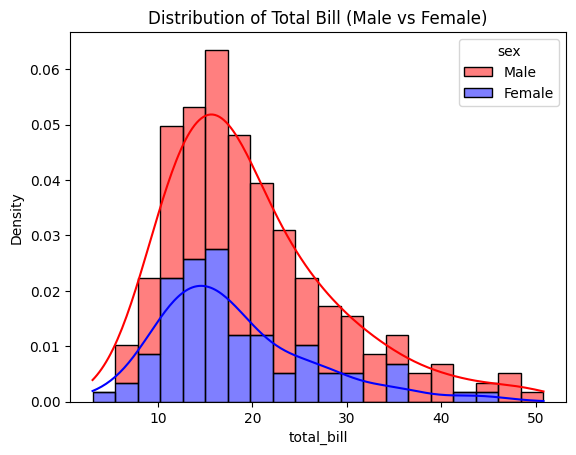

In [22]:
sns.histplot(
    data=tips,
    x="total_bill",
    hue="sex",
    bins=20,
    stat="density",
    kde=True,
    multiple="stack",
    palette={"Male": "red", "Female": "blue"}
)

plt.title("Distribution of Total Bill (Male vs Female)")
plt.show()

### 4. Compare the probability density distribution of total bills for males and females.

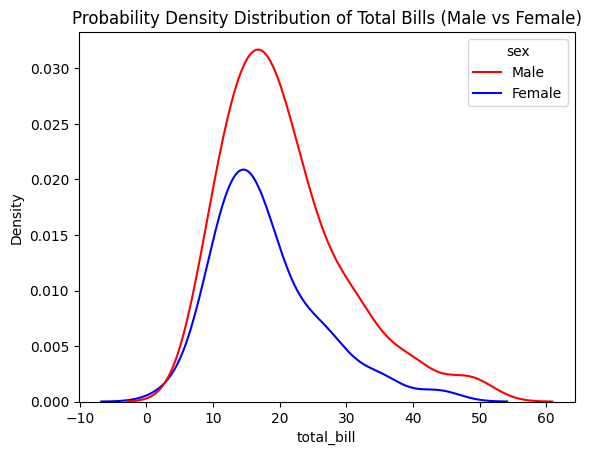

In [23]:
sns.kdeplot(
    data=tips,
    x="total_bill",
    hue="sex",
    fill=False,
    palette={"Male": "red", "Female": "blue"}
)

plt.title("Probability Density Distribution of Total Bills (Male vs Female)")
plt.show()

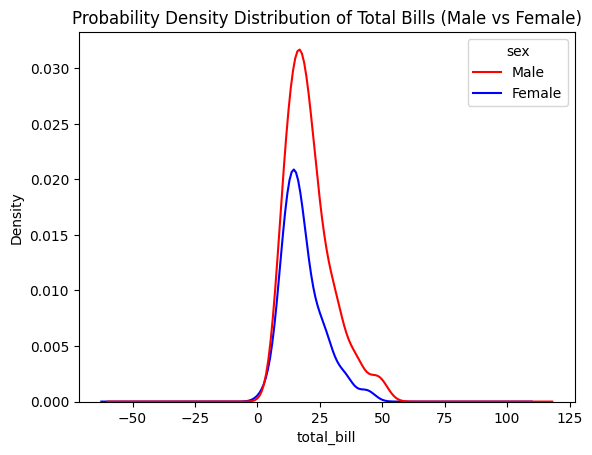

In [24]:
sns.kdeplot(
    data=tips,
    x="total_bill",
    hue="sex",
    fill=False,
    bw_adjust=1,
    cut=20,
    palette={"Male": "red", "Female": "blue"}
)

plt.title("Probability Density Distribution of Total Bills (Male vs Female)")
plt.show()

### 5. Plot the cumulative probability of total bill amounts for males and females (Use a dashed curve).

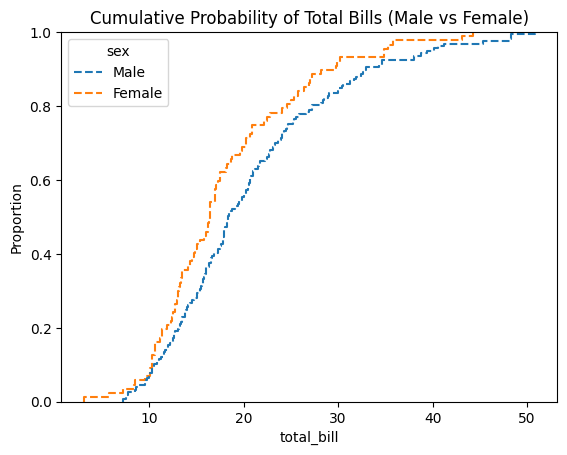

In [25]:
sns.ecdfplot(
    data=tips,
    x="total_bill",
    hue="sex",
    linestyle="--",
    complementary=False
)

plt.title("Cumulative Probability of Total Bills (Male vs Female)")
plt.show()

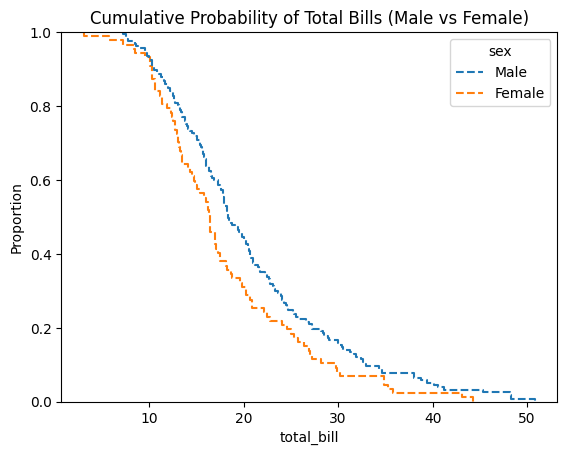

In [26]:
sns.ecdfplot(
    data=tips,
    x="total_bill",
    hue="sex",
    linestyle="--",
    complementary=True
)

plt.title("Cumulative Probability of Total Bills (Male vs Female)")
plt.show()

### 6. Show the variation in spending behavior for males and females across different days of the week.

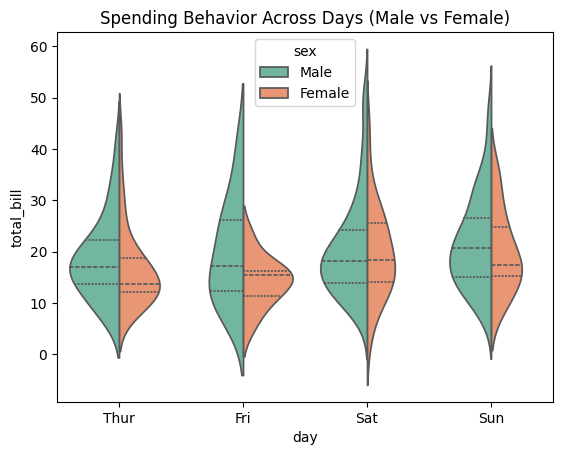

In [27]:
sns.violinplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",
    inner="quartile",
    bw_method="scott",
    palette="Set2",
    split=True
)

plt.title("Spending Behavior Across Days (Male vs Female)")
plt.show()

### 7. Plot the average tip amount for each day of the week and compare for males and females. Show variability of the estimate.

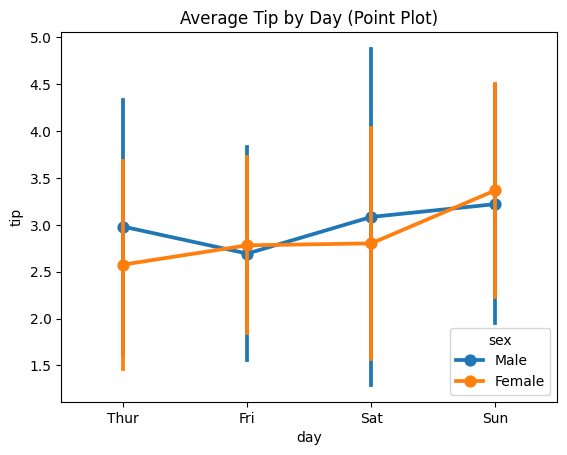

In [28]:
sns.pointplot(
    data=tips,
    x="day",
    y="tip",
    hue="sex",
    errorbar="sd"
)

plt.title("Average Tip by Day (Point Plot)")
plt.show()

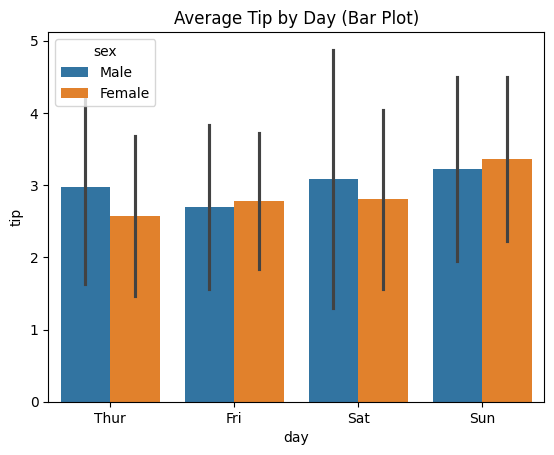

In [29]:
sns.barplot(
    data=tips,
    x="day",
    y="tip",
    hue="sex",
    errorbar="sd"
)

plt.title("Average Tip by Day (Bar Plot)")
plt.show()

### 8. Display the number of customers visiting on each day of the week and compare counts between males and females.

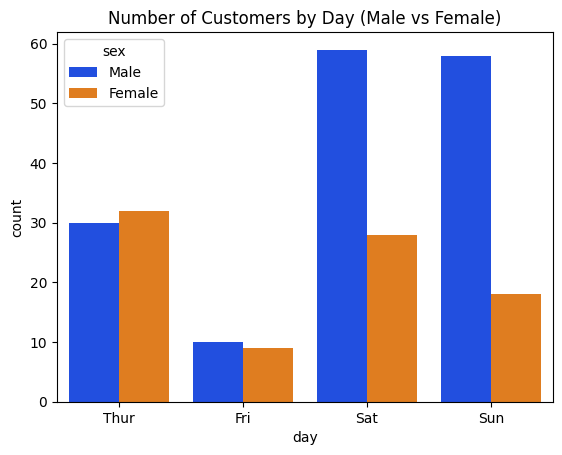

In [30]:
sns.countplot(
    data=tips,
    x="day",
    hue="sex",
    palette="bright"
)

plt.title("Number of Customers by Day (Male vs Female)")
plt.show()

### 9. Show how tip amount depends on total bill and display confidence intervals for the prediction line.

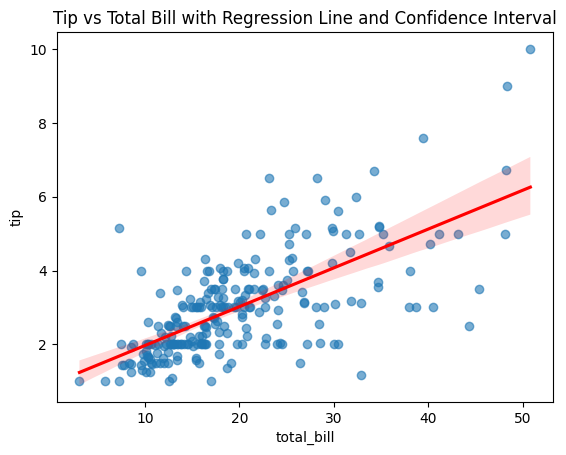

In [31]:
sns.regplot(
    data=tips,
    x="total_bill",
    y="tip",
    ci=95,
    scatter_kws={"alpha":0.6},
    line_kws={"color": "red"}
)

plt.title("Tip vs Total Bill with Regression Line and Confidence Interval")
plt.show()

### 10. Compute the correlation between all numerical variables in the dataset and visualize it using a color-intensity.

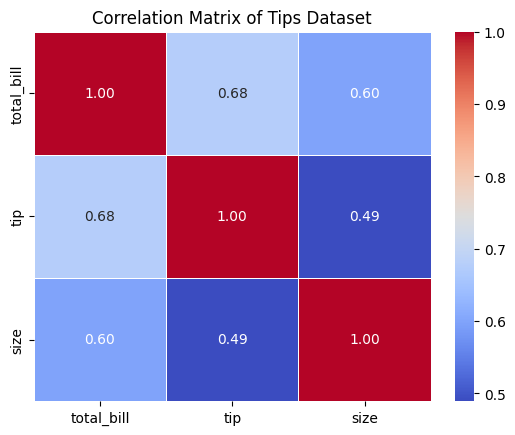

In [32]:
corr = tips.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Tips Dataset")
plt.show()

### 11. Do dinner customers show more variability in spending than lunch customers?

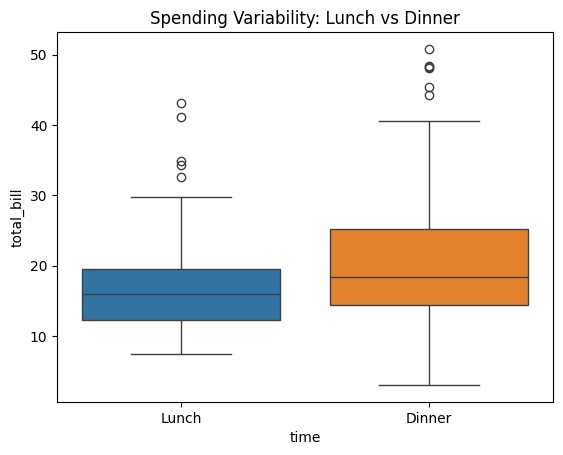

In [33]:
sns.boxplot(
    data=tips,
    x="time",
    y="total_bill",
    hue="time"
)

plt.title("Spending Variability: Lunch vs Dinner")
plt.show()

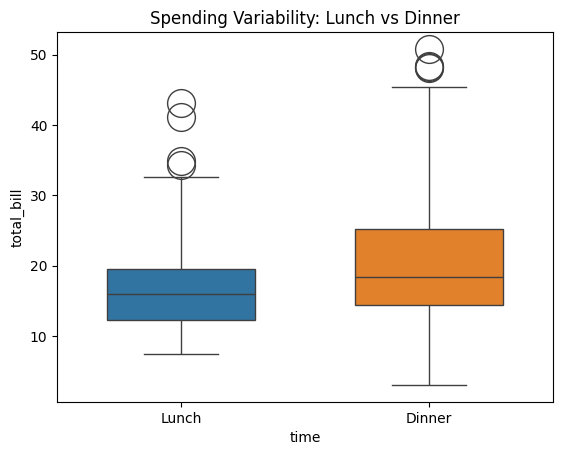

In [34]:
sns.boxplot(
    data=tips,
    x="time",
    y="total_bill",
    hue="time",
    whis=2,
    fliersize=20,
    width=0.6
)

plt.title("Spending Variability: Lunch vs Dinner")
plt.show()

### 12. Is the relationship between total bill and tip linear, and how are the two variables distributed (individually + together)?

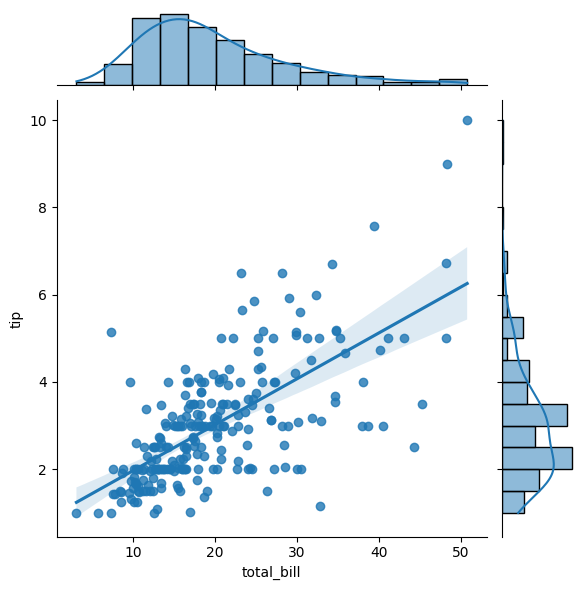

In [35]:
sns.jointplot(
    data=tips,
    x="total_bill",
    y="tip",
    kind="reg"
)

plt.show()

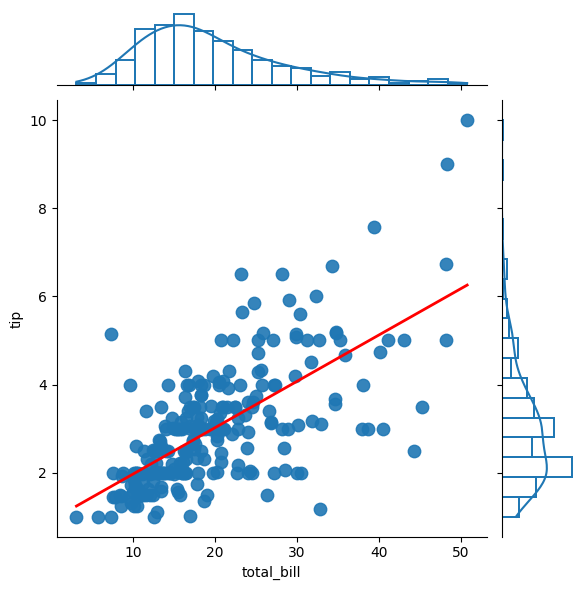

In [36]:
sns.jointplot(
    data=tips, 
    x="total_bill", 
    y="tip", 
    kind="reg", 
    marginal_kws=dict(bins=20, fill=False), 
    joint_kws=dict(
        scatter_kws=dict(s=80, alpha=0.9), 
        line_kws=dict(color="red", linewidth=2), 
        ci=None
    )
)
plt.show()

### 13. Visualize the exact placement of total bill observations along the range and find areas of high and low data concentration. Also plot its density.

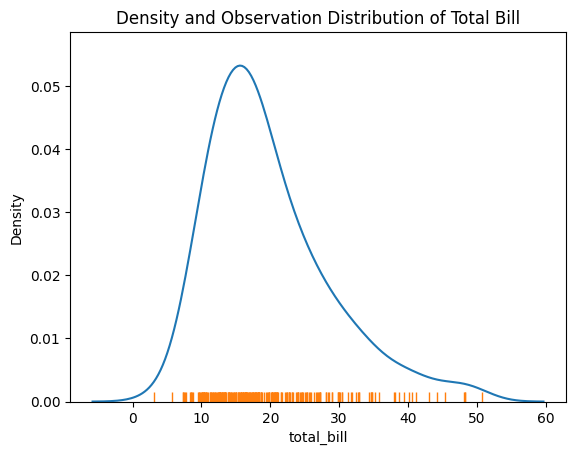

In [37]:
sns.kdeplot(
    data=tips,
    x="total_bill",
    fill=False
)

sns.rugplot(
    data=tips,
    x="total_bill"
)

plt.title("Density and Observation Distribution of Total Bill")
plt.show()

# plotly

## Imports

In [38]:
import plotly.express as px
import plotly.graph_objects as go

## Getting dataset names in plotly

In [39]:
dir(px.data)

['AVAILABLE_BACKENDS',
 'BACKENDS_WITH_INDEX_SUPPORT',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'carshare',
 'election',
 'election_geojson',
 'experiment',
 'gapminder',
 'import_module',
 'iris',
 'medals_long',
 'medals_wide',
 'nw',
 'os',
 'stocks',
 'tips',
 'wind']

In [40]:
gpm = px.data.gapminder()
gpm

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


## 1. Create a line chart showing how life expectancy has changed over time for India and Canada.

Modify the chart so that:

1. Lines are drawn using spline interpolation instead of straight segments.
2. Increase the smoothing level of the spline.
3. Change the line style to ‘longdashdot’.
4. Increase the line width to make trends more visible.
5. Change the line color manually instead of using default color mapping.

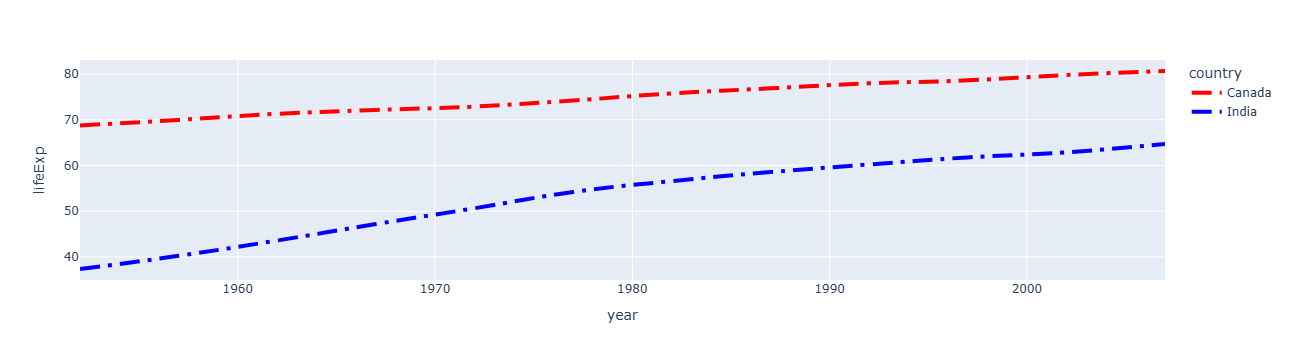

In [41]:
data = gpm[gpm["country"].isin(["India","Canada"])]

fig = px.line(data, x="year", y="lifeExp", color="country")

fig.update_traces(
    line_shape="spline",
    line_smoothing=1.3,
    line_dash="longdashdot",
    line_width=4
)

fig.update_traces(selector=dict(name="India"), line_color="blue")
fig.update_traces(selector=dict(name="Canada"), line_color="red")

fig.show()

## 2. Create a scatter plot to explore the relationship between GDP per capita and life expectancy across continents.

1. Make the marker symbol unique for each continent instead of the default circle.
2. Add borders to the markers for ‘Asia’ with black border color, border width of 2 pixels.
3. Reduce the opacity of other markers.
4. Convert the GDP per capita axis to a logarithmic scale to better visualize the spread of values.
5. Customize the hover information to display:
    - Country name, GDP per capita, Life expectancy, Population
7. Add animation so that the visualization changes across years. Change background color of animation.

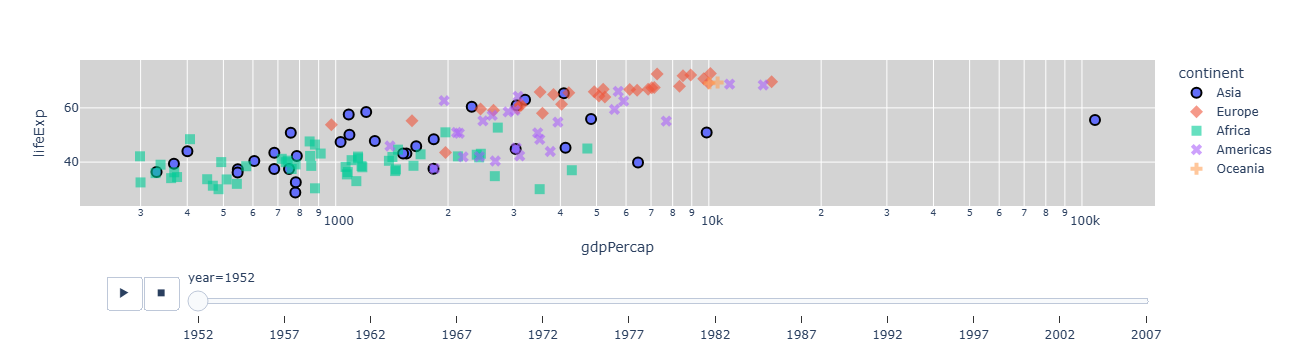

In [42]:
fig = px.scatter(
    gpm,
    x="gdpPercap",
    y="lifeExp",
    color="continent",
    symbol="continent",
    animation_frame="year",
    hover_name="country",
    hover_data=["gdpPercap", "lifeExp", "pop"],
    log_x=True
)

fig.update_traces(marker=dict(size=10, opacity=0.6))

fig.update_traces(
    selector=dict(name="Asia"),
    marker=dict(line=dict(color="black", width=2), opacity=1)
)

fig.update_layout(plot_bgcolor="lightgray")

fig.show()

## 3. Create a box plot to compare the distribution of life expectancy across different continents. Use data from the year 2007.

1. Display Individual Data Points (Show all individual country data points along with the box plot).
2. Display the Mean Value (Add a mean line inside each box to highlight the average life expectancy).
3. Enable Notches in the Box Plot (Helps to indicate confidence around the median).
4. Improve Layout by adding an appropriate title, adjusting box width and rotating the x-axis labels slightly.
5. Save the final plot.

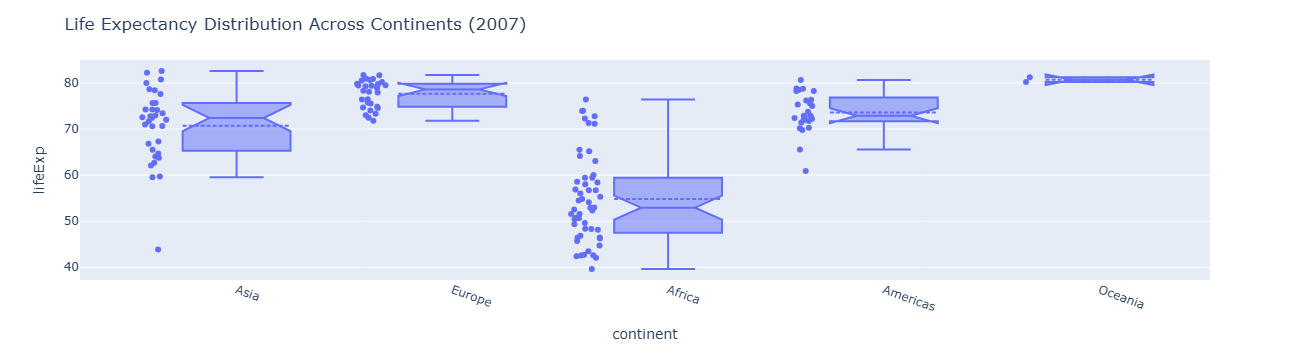

In [43]:
gpm_yer = gpm[gpm["year"] == 2007]

fig = px.box(
    gpm_yer,
    x="continent",
    y="lifeExp",
    points="all",
    notched=True
)

fig.update_traces(boxmean=True, width=0.5)

fig.update_layout(
    title="Life Expectancy Distribution Across Continents (2007)",
    xaxis_tickangle=20
)

fig.write_html("../plots/life_expectancy_boxplot.html")

fig.show()

## 4. Create separate scatter plots using faceting to compare the relationship between GDP per capita and life expectancy across continents.

1. Apply Log Scale to GDP Axis so that country distributions are easier to observe.
2. Add Marker Borders so that overlapping points are easier to distinguish.
3. Adjust Spacing Between Facets.
4. Modify the subplot titles so they clearly indicate the continent name.
5. Improve Layout by adjusting the figure size and positioning the legend appropriately.

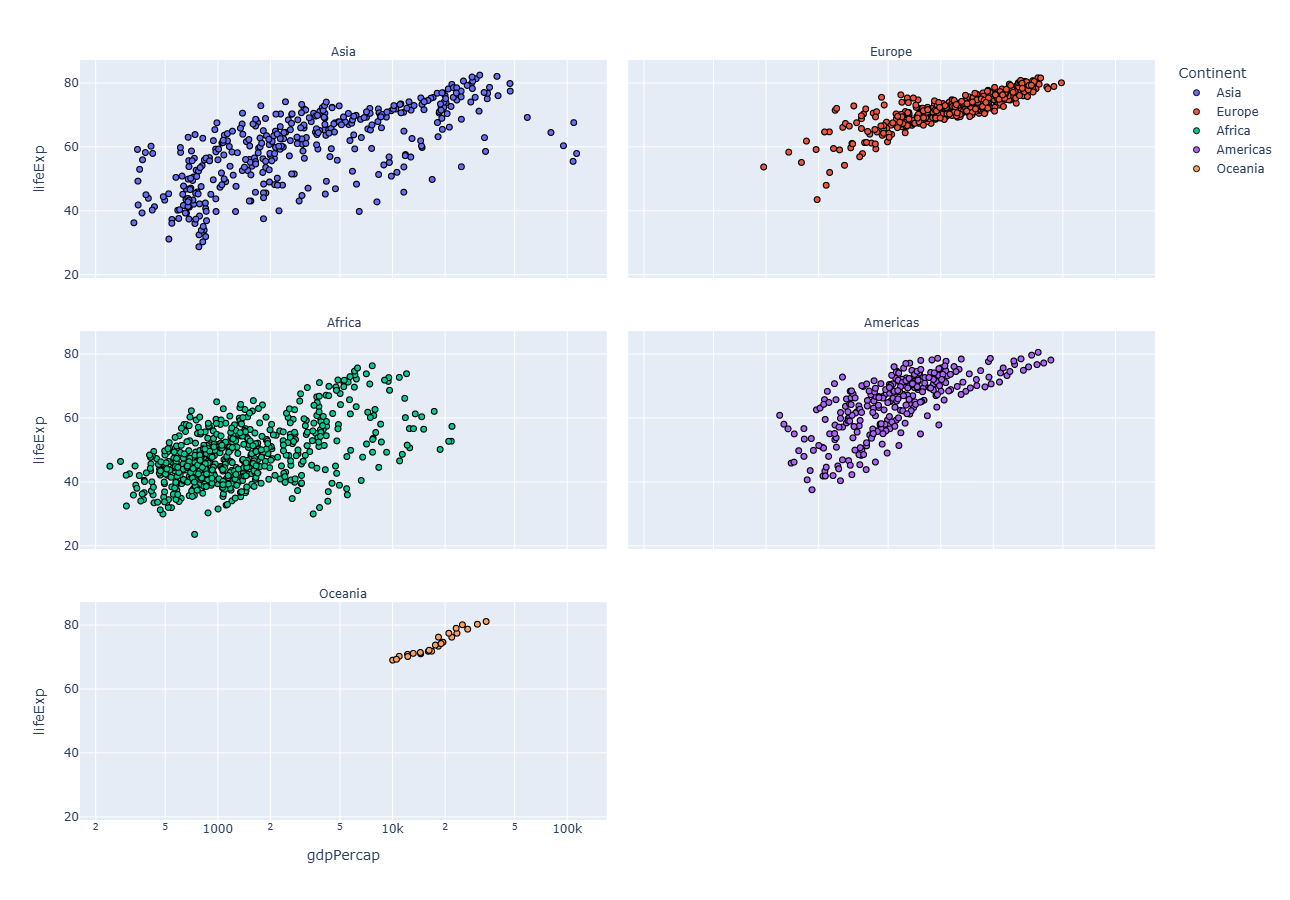

In [44]:
fig = px.scatter(
    gpm,
    x="gdpPercap",
    y="lifeExp",
    color="continent",
    facet_col="continent",
    facet_col_wrap=2,
    log_x=True
)

fig.update_traces(marker=dict(line=dict(color="black", width=1)))

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.update_layout(
    height=900,
    width=900,
    legend_title="Continent",
    margin=dict(t=60)
)

fig.show()

## 5. Create a histogram to study the distribution of life expectancy across countries. Use data from the year 2007.

1. Adjust the Number of Bins.
2. Overlay the Histograms (overlapping each other instead of stacking).
3. Add a Marginal Plot (Include a box plot or violin plot along the axis).
4. Show Probability Distribution (Normalize the histogram so the y-axis represents probability instead of count).
5. Improve Layout by adjusting bar opacity and improving legend placement.

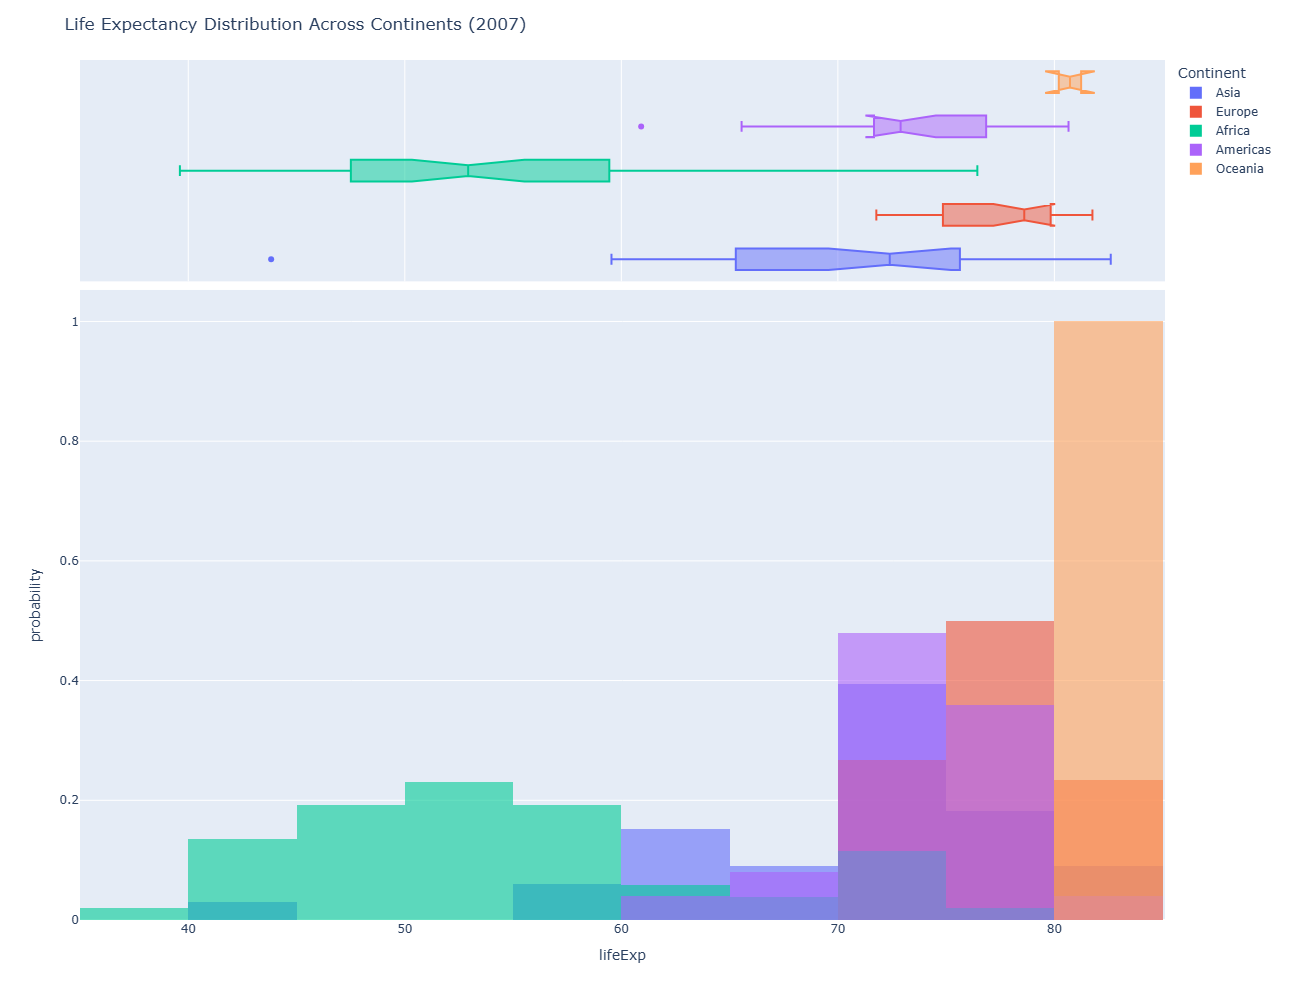

In [45]:
fig = px.histogram(
    gpm[gpm["year"] == 2007],
    x="lifeExp",
    color="continent",
    nbins=10,
    histnorm="probability",
    barmode="overlay",
    opacity=0.6,
    marginal="box"
)

fig.update_layout(
    title="Life Expectancy Distribution Across Continents (2007)",
    legend_title="Continent",
    legend=dict(
        x=1.01,
        y=1
    ),
    height=1000
)

fig.show()

## 6. Create a violin plot to analyze the distribution of life expectancy across continents.

1. Display the box plot inside each violin so that the median and quartiles are visible.
2. Show all individual data points representing countries along with the violin distribution.
3. Adjust the spread of the points so that overlapping points are easier to distinguish.
4. Add a mean line inside each violin to highlight the average life expectancy.
5. Modify the opacity of the violins so that overlapping elements remain visible.

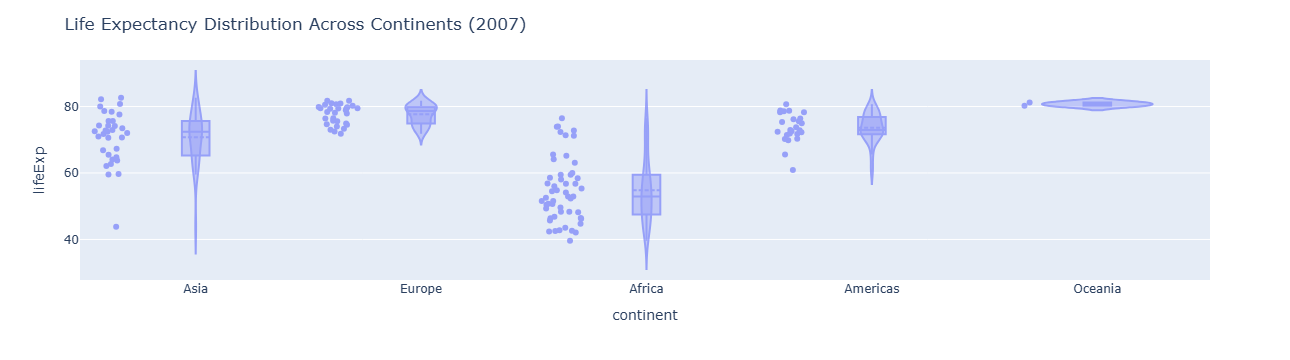

In [46]:
fig = px.violin(
    gpm[gpm["year"] == 2007],
    x="continent",
    y="lifeExp",
    box=True,
    points="all"
)

fig.update_traces(
    jitter=0.4,      # spread points
    meanline_visible=True,
    opacity=0.6
)

fig.update_layout(
    title="Life Expectancy Distribution Across Continents (2007)"
)

fig.show()

## 7. Create a world choropleth map to visualize life expectancy by country. Use data from the year 2007.

1. Apply an Appropriate Color Scale so that differences in life expectancy across countries are clearly visible.
2. Add Country Borders.
3. Change the map projection style to explore how different projections affect the appearance of the world map.
4. Focus on a Specific Region (Asia) by adjusting the map scope.

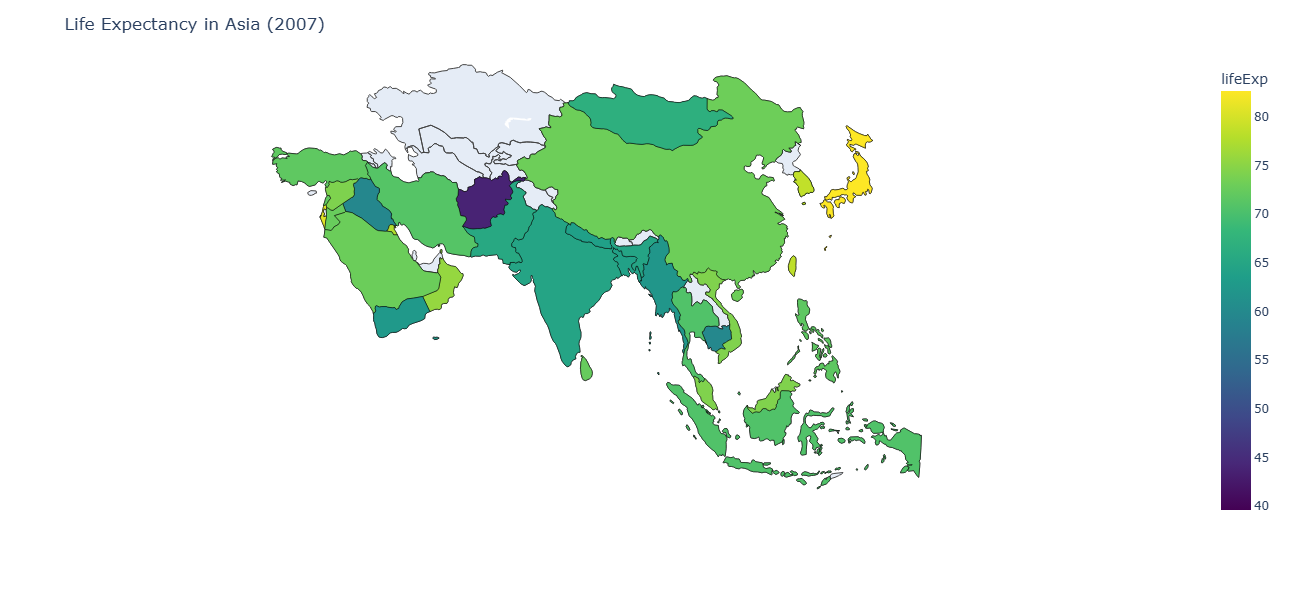

In [47]:
fig = px.choropleth(
    gpm[gpm["year"] == 2007],
    locations="iso_alpha",
    color="lifeExp",
    hover_name="country",
    color_continuous_scale="Viridis",
    scope="asia"
)

fig.update_traces(
    marker_line_color="black",
    marker_line_width=0.5
)

fig.update_geos(
    projection_type="natural earth"
)

fig.update_layout(
    title="Life Expectancy in Asia (2007)",
    height=600
)

fig.show()